# My Paypal Project

Credit card companies must recognize fraudulent credit card transactions so that customers are not charged for items that they did not purchase. Credit card fraud is a fascinating subject for data scientists because of the enormous data sets, real and costly business implications, and potential to solve significant business problems that save millions and millions of dollars/pounds/euros/money.

In global efforts to understand and improve machine learning models and data analysis approaches, some datasets have been made open source.

For this project, you will use a somewhat de-identified dataset of credit card transactions in Europe. The dataset contains transactions made by credit cards in September 2013 by European cardholders.
This dataset presents transactions that occurred in two days, where we have 492 frauds out of 284,807 transactions. The dataset is highly unbalanced. The positive class (frauds) accounts for 0.172% of all transactions.

It contains only numerical input variables, which are the result of a PCA transformation. Unfortunately, we cannot provide the original features and more background information about the data due to confidentiality issues. Features V1, V2, … V28 are the principal components obtained with PCA. The only features that have not been transformed with PCA are 'Time' and 'Amount.' Feature 'Time' contains the seconds elapsed between each transaction and the first transaction in the dataset. The feature 'Amount' is the transaction Amount; for example-dependant cost-sensitive learning. Feature 'Class' is the response variable, and it takes value 1 in case of fraud and 0 otherwise.

Given the class imbalance ratio, we recommend measuring the accuracy using the Area Under the Precision-Recall Curve (AUPRC). Confusion matrix accuracy is not meaningful for unbalanced classification.

You have been hired by FriendPay, a competitor of PayPal, to help them improve their credit card fraud identification system. They are having difficulty identifying which transactions are or are not fraudulent, and this is creating significant business problems that are costing them a lot in missed transaction fees.

*Your mission*

> Your mission is to build a fraud detection model using the dataset that has been provided and in doing so, increase revenue from transaction fees.

What are the success criteria?

> During our next meeting, you will have to show us some data (plot? report?) of what you've been building.
You will also be evaluated on your model's impact on the business. We need to make our customers happy by denying fraudulent transactions and allowing genuine ones.

What to expect?

> A presentation with slides on how you classified, as well as assumptions, implications, and other important information.
Code that the DevOps team should be able to push to production.

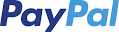

# Technical specification
Companies that involve a lot of transactions with the use of cards need to find anomalies in the system. Build a fraud detection model on credit cards. Use the transaction and their labels as fraud or non-fraud to detect if new transactions made by the customer are fraud or not.

Learning outcomes: the five stages of your project

1. Data Collecting / Cleaning (see below)
2. Data Exploration
3. Data Visualization
4. Machine Learning
5. Communication

# Import libraries

NumPy and Pandas provided the foundation for data manipulation and analysis, allowing us to handle arrays and perform operations on datasets. Matplotlib and Seaborn enabled us to create visualizations to better understand our data and gain insights. We used functions from Scipy.stats for statistical testing, including Shapiro-Wilk test, probability plots, and the Mann-Whitney U test.

To address the challenge of imbalanced datasets, we utilized the SMOTE algorithm from the imbalanced-learn library, which helps to generate synthetic samples of the minority class, improving the balance of the dataset.

For evaluating machine learning models, we imported metrics such as confusion matrix and accuracy score from Scikit-learn. We also utilized the train_test_split function from Scikit-learn to split our data into training and testing sets.

Lastly, we applied the Random Forest Classifier algorithm from Scikit-learn's ensemble module for building a classification model.

By incorporating these libraries and techniques, we can gain valuable insights from data, handle imbalanced datasets, evaluate model performance, and build machine learning models effectively.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, probplot, mannwhitneyu
from imblearn.over_sampling import SMOTE
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')

# Collecting data

The next step in Data Science after importing necessary libraries reading data!

>The provided code represents a reading function that loads a dataset with columns named "Time," "V1" through "V28," "Amount," and "Class" into a Pandas DataFrame.

> The "Time" column represents the time elapsed between transactions, while "V1" through "V28" are numerical features extracted from the transactions. The "Amount" column denotes the transaction amount, and the "Class" column indicates whether a transaction is classified as fraudulent (1) or not (0).

>This reading function allows us to import and access the dataset easily, enabling further analysis and manipulation of the data.

In [4]:
def read_data():
    data = pd.read_csv('/kaggle/input/my-paypal-creditcardcsv/my_paypal_creditcard.csv')
    return data
data = read_data()
data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


# Checking NaN values

Checking NaN values is important part of processing and preparing data to machine learning part of projects.
There is no NaN values as we can see,So, in this part our data is clean!

In [5]:
def checking_values(data):
    return data.isna().sum()
check = checking_values(data)
check

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

# Exploration Data

> First, it displays the descriptive statistics of the dataset using the describe() function, giving us an overview of the central tendencies, dispersion, and distribution of the numerical features. This information helps us understand the data's general characteristics and identify potential outliers or anomalies.

> Next, it presents information about the dataset using the info() function. This includes the data type of each column and the total number of non-null values. This summary assists in identifying missing values and ensuring data integrity.

> Lastly, the function showcases the column names of the dataset using the columns.values attribute. This is helpful for understanding the available features and referencing specific columns during analysis.

By utilizing this function, we can quickly obtain an overview of the dataset's structure, statistical properties, and column information. This EDA process aids in gaining initial insights and forming a solid foundation for further data exploration and analysis.

In [35]:
def exploration_data(data):
    print("Data Describing: ")
    display(data.describe())
    print("Information about data: ")
    display(data.info())
    print("Columns of data: ")
    display(data.columns.values)
explorated_data = exploration_data(data)
explorated_data

Data Describing: 


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


Information about data: 

<class 'pandas.core.frame.DataFrame'>

RangeIndex: 284807 entries, 0 to 284806

Data columns (total 31 columns):

 #   Column  Non-Null Count   Dtype  

---  ------  --------------   -----  

 0   Time    284807 non-null  float64

 1   V1      284807 non-null  float64

 2   V2      284807 non-null  float64

 3   V3      284807 non-null  float64

 4   V4      284807 non-null  float64

 5   V5      284807 non-null  float64

 6   V6      284807 non-null  float64

 7   V7      284807 non-null  float64

 8   V8      284807 non-null  float64

 9   V9      284807 non-null  float64

 10  V10     284807 non-null  float64

 11  V11     284807 non-null  float64

 12  V12     284807 non-null  float64

 13  V13     284807 non-null  float64

 14  V14     284807 non-null  float64

 15  V15     284807 non-null  float64

 16  V16     284807 non-null  float64

 17  V17     284807 non-null  float64

 18  V18     284807 non-null  float64

 19  V19     284807 non-null  float64

 2

None

Columns of data: 


array(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9',
       'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18',
       'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27',
       'V28', 'Amount', 'Class'], dtype=object)

# Analyzing Data

Analyzing data is also important part of project, if you will not alanyze your data you can't understand data. It hears like "If you skip the data analysis step, you will miss out on valuable insights that can greatly impact the success of your project."

By analyzing the data, you can identify patterns, trends, and relationships within the dataset. This analysis helps in making informed decisions, formulating hypotheses, and designing appropriate strategies for further exploration or modeling.

One of the first parts of analyzing is "Checking distribution". With checking distribution we can understand: "Can we use parametric tests and check hypothesis". If our data has Normal distribution, we can do so many interesting parametric tests. If data is not Normal distributed we have to use none parametric tests. 

In this case our each columns dataset wasn't normal distributed :( Because transactions was "Hashed" by bank to don't see real data:)

Here i checked distribution by using shapiro test, this popular statistical test to checking distribution.

In [65]:
def checking_distributon(data):
    """Checking normal distribution is important part of analyzing data,
    because if your data doesn't follows to normal distribution, you can't analyze very well
    and test in some methods like T-test, Anova and Chisquare and so on."""
    alpha = 0.05
    for i in data:
        stats, p_value = shapiro(data[i].values)
        if alpha < p_value:
            print("Data follows normal Distribution -> ", p_value)
        else:
            print("Data does not follow a normal distribution -> ", p_value)
        
explained_data = checking_distributon(data)
explained_data

Data does not follow a normal distribution ->  0.0

Data does not follow a normal distribution ->  0.0

Data does not follow a normal distribution ->  0.0

Data does not follow a normal distribution ->  0.0

Data does not follow a normal distribution ->  0.0

Data does not follow a normal distribution ->  0.0

Data does not follow a normal distribution ->  0.0

Data does not follow a normal distribution ->  0.0

Data does not follow a normal distribution ->  0.0

Data does not follow a normal distribution ->  0.0

Data does not follow a normal distribution ->  0.0

Data does not follow a normal distribution ->  0.0

Data does not follow a normal distribution ->  0.0

Data does not follow a normal distribution ->  2.3147049526166136e-31

Data does not follow a normal distribution ->  0.0

Data does not follow a normal distribution ->  0.0

Data does not follow a normal distribution ->  0.0

Data does not follow a normal distribution ->  0.0

Data does not follow a normal distribution ->

We can also vizualize our data distributions!

Our shapiro test was right about this data. Our data is not normal as we can see below.

So, we have to analyze with none parametric tests. I repeat, because our data is not distributed normally.
Visualizing the data distributions allows us to gain insights into the shape, spread, and skewness of the data. By examining histograms, box plots, or density plots, we can identify any deviations from normality, such as skewed or multimodal distributions. These visualizations provide a clear picture of the data's characteristics and assist in selecting appropriate statistical tests and modeling techniques.

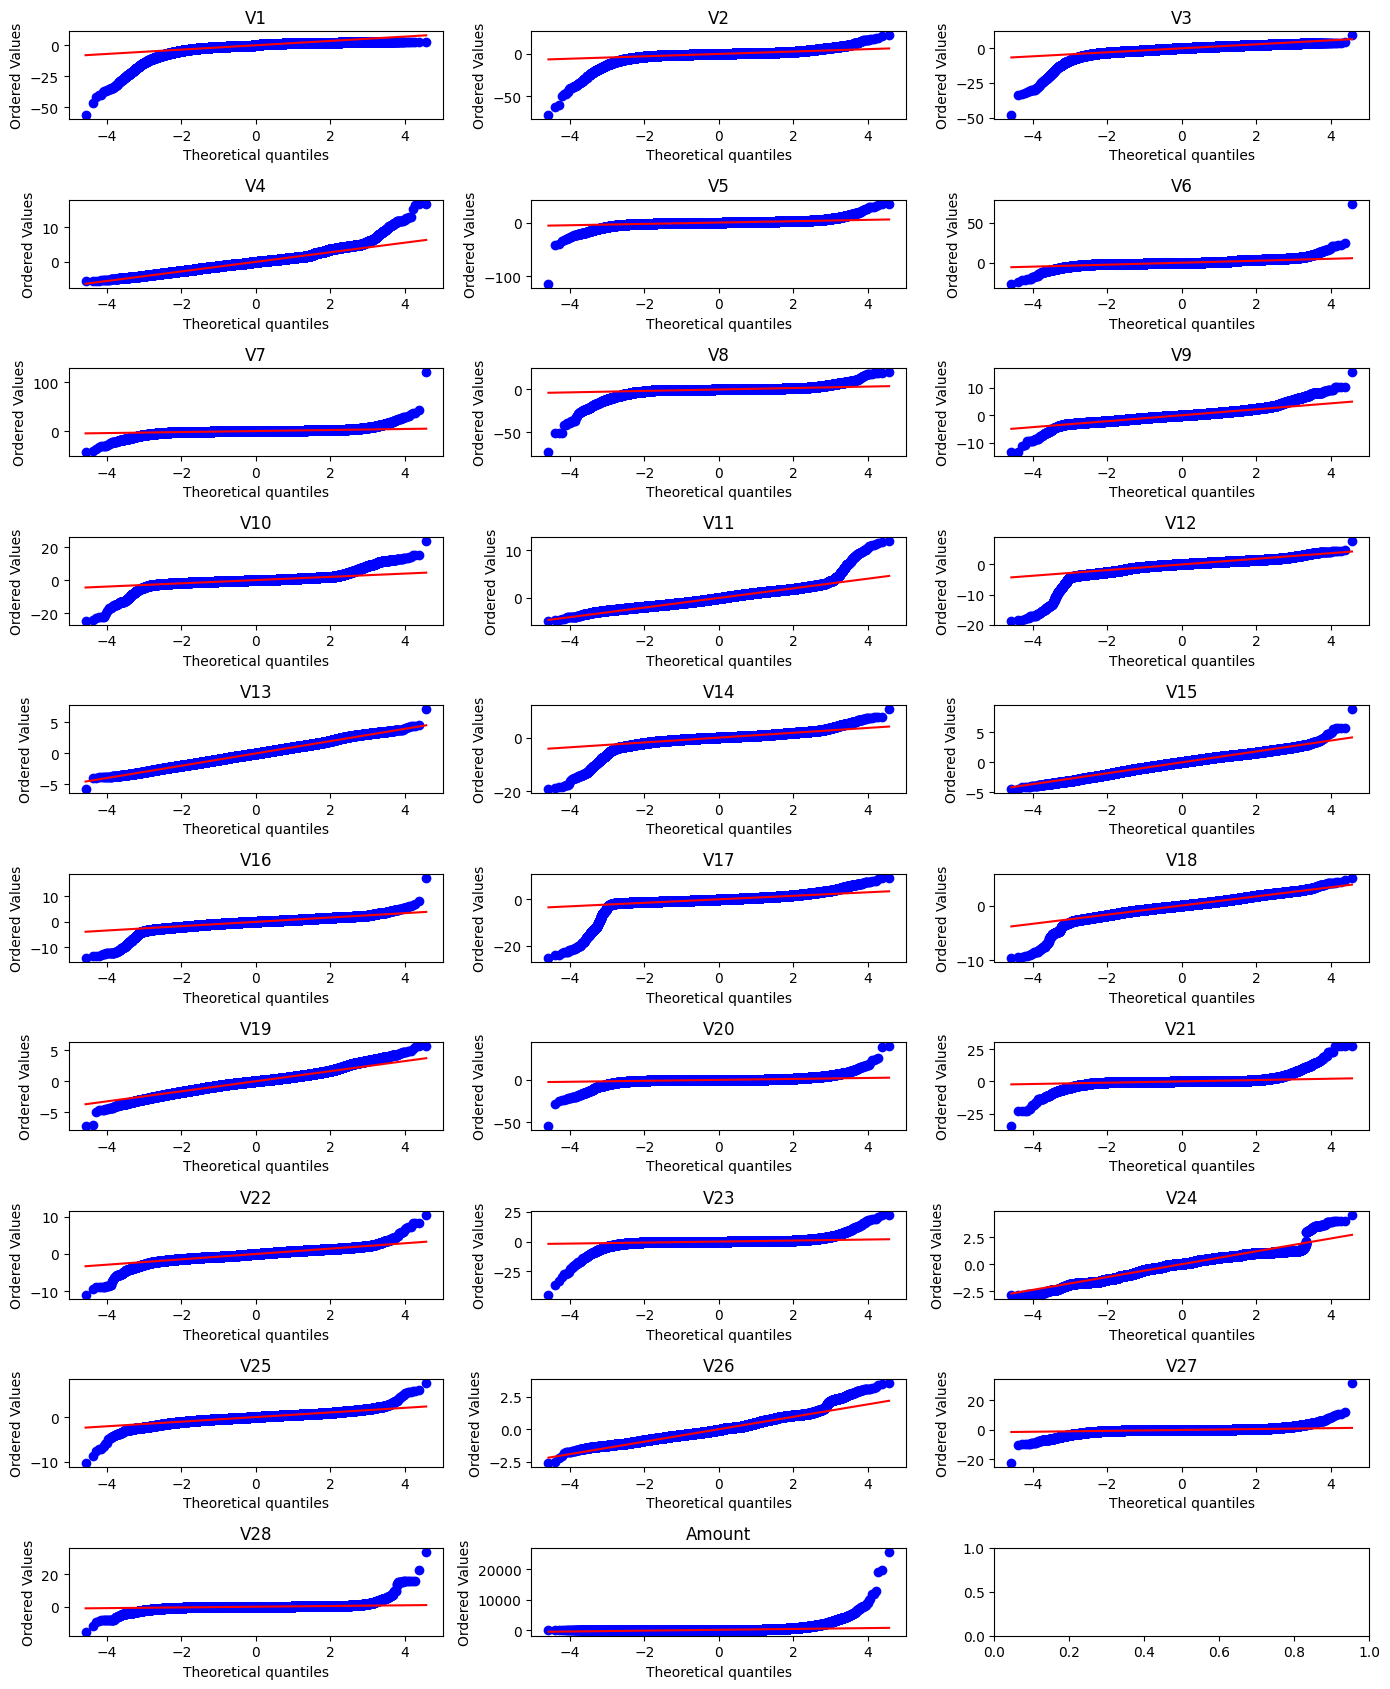

None


In [6]:
def plot_distributions(data):
    fig, axes = plt.subplots(10,3, figsize=(14, 17))
    axes = axes.flatten()
    for i, v in enumerate(data.iloc[:, 1:-1]):
        ax = axes[i]
        probplot(data[v], dist='norm', plot=ax)
        ax.set_title(v)
    plt.tight_layout()
    plt.show()
    
print(plot_distributions(data))

By plotting the time values of fraudulent transactions, we can observe any patterns or anomalies in the timing of these fraudulent activities. This visualization helps us understand if there are specific periods or trends when fraud is more prevalent.

Similarly, the plot of non-fraudulent transactions' time distribution allows us to compare it with fraudulent transactions and identify any significant differences. This comparison aids in distinguishing patterns unique to fraudulent transactions.

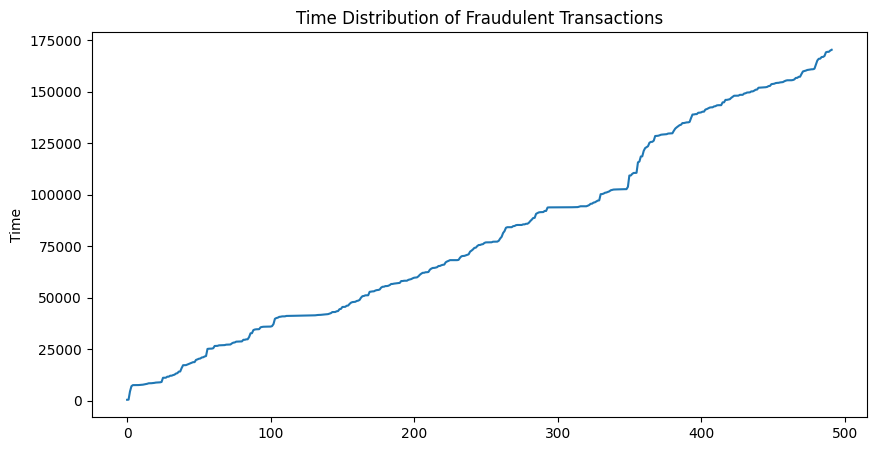

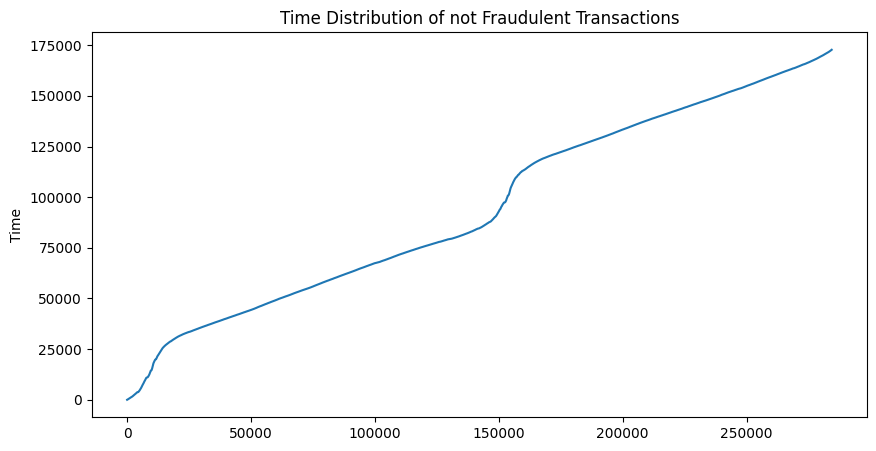

None


In [141]:
def plot_time(data):
    fraud_transactions = data[(data["Class"] == 1)] # This data represent fraud of transaction
    plt.figure(figsize=(10, 5))
    plt.plot(fraud_transactions['Time'].values)
    plt.title("Time Distribution of Fraudulent Transactions")
    plt.ylabel("Time")
    plt.show()
    
    not_fraud_transactions = data[(data["Class"] != 1)]
    plt.figure(figsize=(10, 5))
    plt.plot(not_fraud_transactions['Time'].values)
    plt.title("Time Distribution of not Fraudulent Transactions")
    plt.ylabel("Time")
    plt.show()
print(plot_time(data))

This function compares the time distribution between fraudulent and non-fraudulent transactions in the dataset. It performs a Mann-Whitney U test to determine if there is a significant difference between the two groups.

If the p-value from the test is less than the chosen significance level (alpha), it suggests that there is a statistically significant difference in the time distribution between frauds and real clients. On the other hand, if the p-value is greater than alpha, it indicates that there is no significant difference.

The function also visualizes the time distribution using kernel density estimation (KDE) plots for both fraudulent and non-fraudulent transactions. This allows for a visual comparison of the shape and patterns in the time distribution between the two groups.

By analyzing the results and examining the plots, we can gain insights into any distinct temporal patterns associated with fraudulent transactions. This information can be valuable for developing fraud detection and prevention strategies based on timing characteristics.

We have a difference between Frauds and real customers on time Transaction


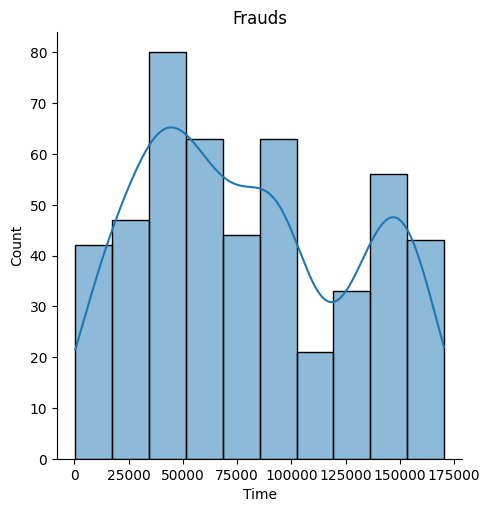

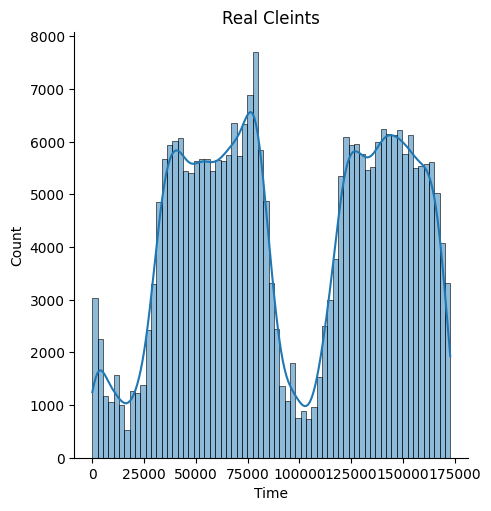

In [169]:
def compare_frauds_with_clients(data):
    frauds = data[(data["Class"] == 1)]
    not_frauds = data[(data["Class"] == 0)]
    stats, p_value = mannwhitneyu(frauds["Time"].values, not_frauds["Time"].values)
    alpha = 0.05
    if alpha < p_value:
        print("There is no difference between Frauds and real customers on time Transaction")
    else:
        print("We have a difference between Frauds and real customers on time Transaction")
    sns.displot(data=frauds, x="Time", kde=True)
    plt.title("Frauds")
    plt.show()
    sns.displot(data=not_frauds, x="Time", kde=True)
    plt.title("Real Cleints")
    plt.show()
comparing = compare_frauds_with_clients(data)
comparing

By examining the histograms, we can gain insights into the differences in transaction amounts between frauds and real clients. The overlapping or distinct patterns in the histograms can provide information about the range, frequency, and distribution of transaction amounts associated with fraudulent activities.

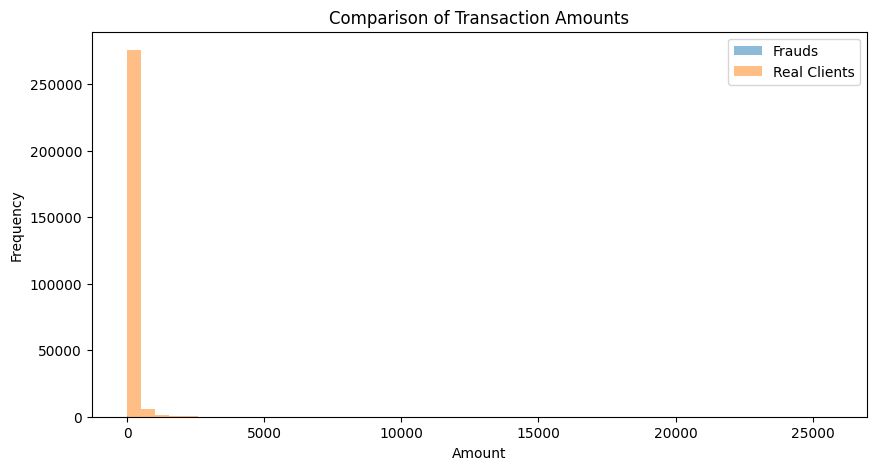

In [187]:
def comparing_amount(frauds, real_clients):
    plt.figure(figsize=(10, 5))
    plt.hist(frauds["Amount"], bins=50, alpha=0.5, label="Frauds")
    plt.hist(real_clients["Amount"], bins=50, alpha=0.5, label="Real Clients")

    plt.xlabel("Amount")
    plt.ylabel("Frequency")
    plt.title("Comparison of Transaction Amounts")
    plt.legend()
    plt.show()

frauds = data[(data["Class"] == 1)]
real_clients = data[(data["Class"] == 0)]
amount = comparing_amount(frauds, real_clients)
amount

As we can see there is neutral correlation between time and amount

The scatterplot provides a visual representation of the relationship between the transaction amount and time. It allows us to observe any patterns or trends in the data points and identify any potential correlation.

The heatmap, on the other hand, displays the correlation coefficient between the time and amount variables. A correlation coefficient near 0 indicates a neutral or no correlation between the two variables.

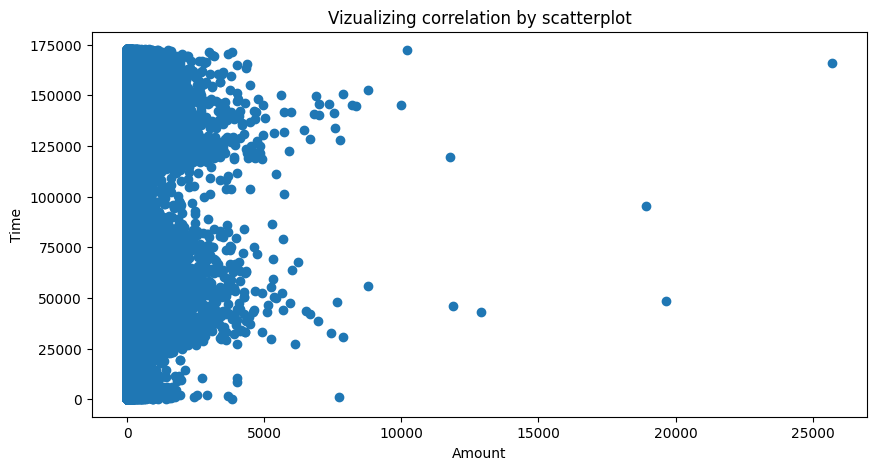

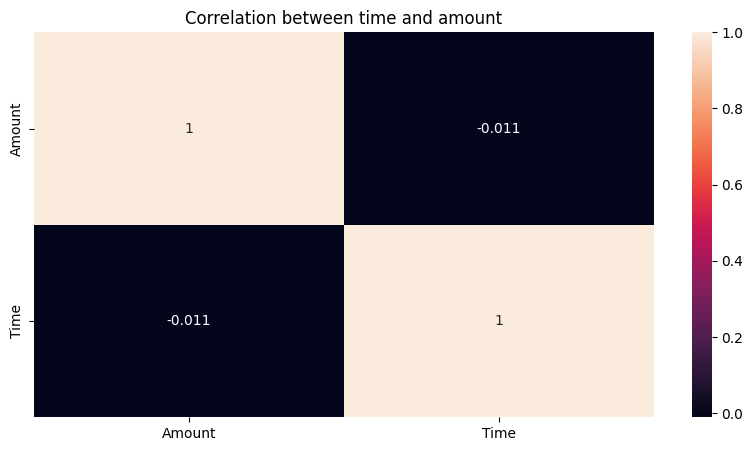

In [209]:
def checking_correlation_time_and_amount(data):
    x = data["Amount"]
    y = data["Time"]
    plt.figure(figsize=(10, 5))
    plt.scatter(x, y)
    plt.title("Vizualizing correlation by scatterplot")
    plt.xlabel("Amount")
    plt.ylabel("Time")
    plt.show()
    
    df = pd.concat([x, y], axis=1)
    correlation = df.corr()
    plt.figure(figsize=(10, 5))
    plt.title("Correlation between time and amount")
    sns.heatmap(correlation, annot=True)
    plt.show()
correlation_between_time_and_ammount = checking_correlation_time_and_amount(data)
correlation_between_time_and_ammount

# Checking balance of data

The bar plot provides a visual representation of the data balance by displaying the number of instances in each class. This helps us understand whether the dataset is imbalanced, meaning one class significantly outweighs the others, or if the classes are relatively balanced.

So, our data inbalanced data! If we will predict this data, we will get overfitting. 

Overfitting refers to a modeling problem where a machine learning algorithm learns the training data too well, to the point that it memorizes the noise or random fluctuations in the data. As a result, the model becomes overly specialized and fails to generalize well to new, unseen data.

We should make it balanced to correctly predict the data!

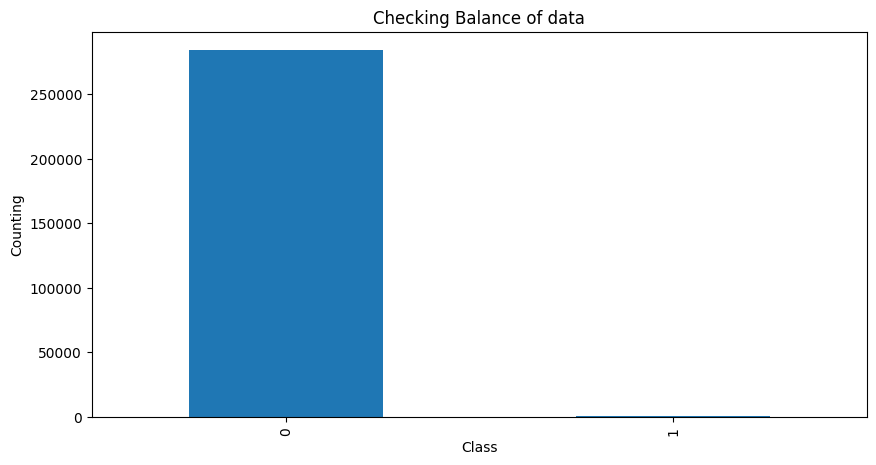

Class
0    284315
1       492
Name: count, dtype: int64

In [228]:
def check_balance_of_data(data):
    class_counts = data.Class.value_counts()
    plt.figure(figsize=(10, 5))
    class_counts.plot(kind="bar")
    plt.title("Checking Balance of data")
    plt.ylabel("Counting")
    plt.show()
check_balance = check_balance_of_data(data)
check_balance

# Machine Learning

> 1. Making Inbalanced data balanced to avoid overfitting 

SMOTE (Synthetic Minority Oversampling Technique) algorithm to balance the dataset by generating synthetic samples of the minority class (fraudulent transactions) to match the majority class (non-fraudulent transactions). This helps address the issue of imbalanced data, where the number of instances in one class is significantly higher than the other.

By applying SMOTE, the function creates a new balanced dataset with equal representation of both classes. This balanced dataset can then be used for training machine learning models to ensure fair and accurate predictions for both classes.

In [247]:
def making_balanced(data):
    X = data.drop("Class", axis=1)
    y = data.iloc[:, -1]
    
    smote = SMOTE()
    X_resampled, y_resampled = smote.fit_resample(X, y)
    return X_resampled, y_resampled
X_resampled, y_resampled = making_balanced(data)

Let's check is there resampled data or balanced our data when we used SMOTE or not.

This resampling technique helps ensure that both classes are adequately represented in the dataset, allowing for more reliable and accurate model training. By balancing the data, we can mitigate the potential bias towards the majority class, improving the performance of our machine learning models in detecting fraudulent transactions.

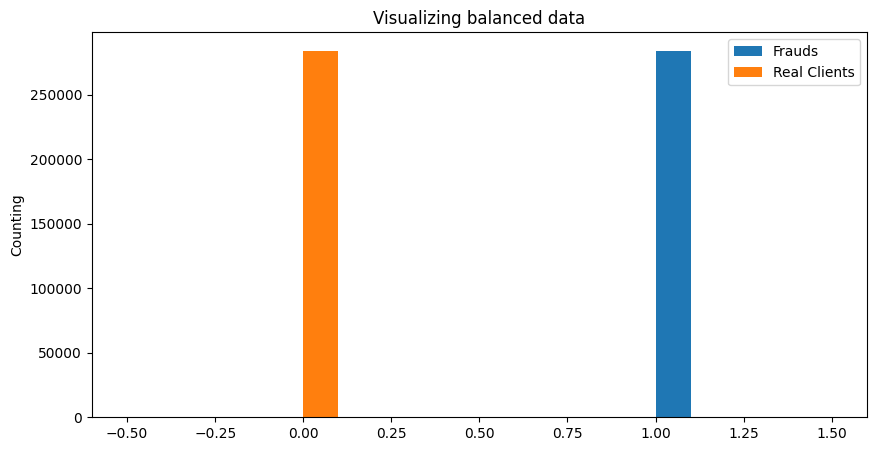

In [246]:
def checking_is_resampled(y_resampled):
    y_values = y_resampled.values
    frauds = y_values[y_values == 1]
    real_clients = y_values[y_values != 1]
    plt.figure(figsize=(10, 5))
    plt.hist(frauds, label="Frauds")
    plt.hist(real_clients, label="Real Clients")
    plt.title("Visualizing balanced data")
    plt.ylabel("Counting")
    plt.legend()
    plt.show()
    
checking_is_resampled(y_resampled)

The training set is used to train the machine learning model, while the testing set is used to evaluate its performance.

By specifying a test size of 0.3 (30% of the data) and setting a random state of 42, we ensure that the splitting process is reproducible and that the testing set is representative of the overall data distribution. This helps us assess how well our model generalizes to unseen data.

In [253]:
def train_test_splitting(X_resampled, y_resampled):
    
    return train_test_split(X_resampled, y_resampled, test_size=0.3, random_state=42)

X_train, X_test, y_train, y_test = train_test_splitting(X_resampled, y_resampled)

we construct a Random Forest Classifier model with 40 estimators and set the number of jobs to 1 for parallel processing. By setting the random state to 10, we ensure reproducibility of results.

The model is then fitted using the training data (X_train and y_train) to learn the patterns and relationships in the data. This step involves training the model to make accurate predictions and detect fraudulent transactions based on the provided features.

This part of the blog post highlights the essential step of building and fitting the machine learning model using the Random Forest algorithm, which plays a crucial role in identifying and classifying fraudulent transactions.

In [257]:
def building_model_and_fitting(X_train, X_test, y_train, y_test):
    model = RandomForestClassifier(n_estimators=40, n_jobs=1, random_state=10)
    return model.fit(X_train, y_train)
fitted_model = building_model_and_fitting(X_train, X_test, y_train, y_test)

We utilize the fitted model to make predictions on the test data (X_test) and evaluate its performance. The predicted values are stored in the "y_predict_test" variable.

To assess the model's accuracy, we calculate its score using the test data and trained data. The score represents the proportion of correctly classified instances. A higher score indicates better predictive performance.

The evaluated results provide insights into the model's effectiveness in identifying fraudulent transactions. It showcases the importance of evaluating the model's performance to assess its reliability and suitability for real-world applications.

YES! Our accuracy on test part is 99.99%. This is better! and in our training part is 100%. It means our balanced data works correctly.

When we built model and evaluated, For example our test score is 50% and trainng score 90%, it means our data predicted is not correclty! This is very important.

In [269]:
def predicting_evaluating(X_test, y_test):
    y_predict_test = fitted_model.predict(X_test)
    return f"Score with test data: {fitted_model.score(X_test, y_test)}  Score with trained data: {fitted_model.score(X_train, y_train)}"
evaluated_data = predicting_evaluating(X_test, y_test)
evaluated_data

'Score with test data: 0.9999062073170016  Score with trained data: 1.0'

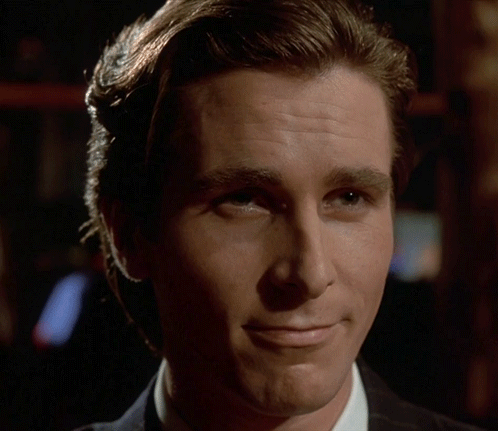

The resulting heatmap demonstrates that our balanced data works effectively in this visualization. It indicates how well the model performs in correctly classifying fraudulent and non-fraudulent transactions.



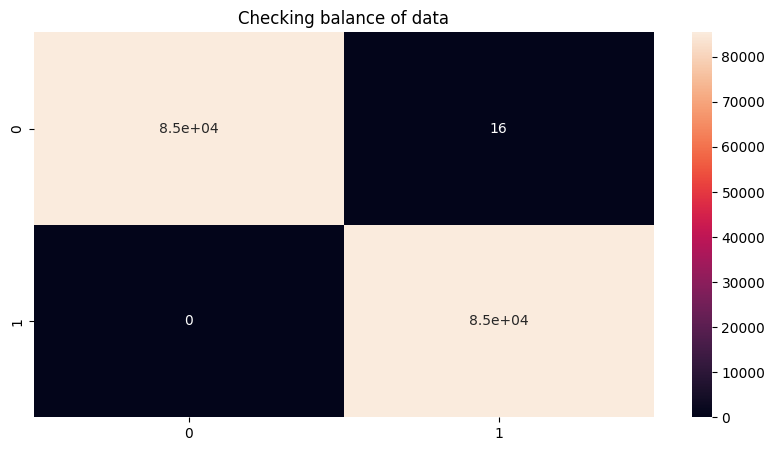

In [266]:
y_predict = fitted_model.predict(X_test)
plt.figure(figsize=(10, 5)) 
plt.title("Checking balance of data")
sns.heatmap(confusion_matrix(y_test, y_predict), annot=True)
plt.show() # Our balanced data works correclty in this vizualization 

By addressing the issue of imbalanced data and employing appropriate techniques, we improved the model's ability to detect fraud, leading to better outcomes in credit card fraud detection.